In [151]:
#Mersenne Twister as the core generator
import random as rand
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy as sp
import excel

In [152]:
n = 8
p = 0.563
TEST = 200
lambda2 = 1.24
#Data_for_hyperexp

q1 = 0.16
q2 = 0.59
q3 = 0.25
l1 = 1.24
l2 = 0.64
l3 = 0.58

In [153]:
def save_table(array,t,name):
    string = []
    table_legacy = []
    for i in range (TEST // 10):
        string = []
        for j in range (10):
            string.append(array[i*10 + j])
            table_legacy.append(string) 
        t.loc[i] = string
    save_to_excel(t,name)

In [154]:
def save_to_excel(data, filename):
    writer = pd.ExcelWriter(filename + '.xlsx', engine='xlsxwriter')
    data.to_excel(writer, sheet_name='AnotherSheet')
    writer.close()

In [155]:
def Text(Xi2,Xi22,Xi_homogeneous, loops):
    if (Xi2 < sp.stats.chi2.ppf(1 - 0.05, loops) ):
        print("сгенерированные случайные величины стандартным алгоритмом соответствуют распределению")
        print("Хи квадрат равен : ", Xi2 )
    else:
        print("Error")
    if (Xi22 < sp.stats.chi2.ppf(1 - 0.05, loops) ):
        print("сгенерированные случайные величины командой библиотеки scipy соответствуют распределению")
        print("Хи квадрат равен : ", Xi22 )
    else:
        print("Error")
    if (Xi_homogeneous < sp.stats.chi2.ppf(1 - 0.05, loops ) ):
        print("выборки однородны")
        print("Хи квадрат для однородности : ", Xi_homogeneous )
        print("Хи критическая :", sp.stats.chi2.ppf(1 - 0.05, loops))
        print('\n')
    else:
        print("Error")


In [156]:
class Generator:
    def __init__(self,TEST,n,p, lambda2, q1, q2, q3, l1, l2, l3):
        

        self.Machine_error = 0.00001 ##such a big error is allowed for this task
        
        self.chunk = 11
        self.TEST = TEST
        #number of  experiment
        self.n = n
        #probability of successed experiment 
        self.p = p
        #lambda for Expon
        self.lambda2 = lambda2
        
        #Standart algorythm generated numbers
        self.Eps_array = []
        #SP func numbers
        self.Eps_array2 = []
        #Probability 
        self.p_eps = []
        
        #Xi^2
        self.Xi  = 0
        self.Xi2 = 0
        
        #m for continous
        self.m = 1 + math.log(self.TEST)//math.log(2)
        self.continous_flag = 0
        self.exp_flag = 0
        self.hyper_flag = 0
        
        self.q1 = q1
        self.q2 = q2
        self.q3 = q3
        self.l1 = l1
        self.l2 = l2
        self.l3 = l3
        
        
        self.table1 = pd.DataFrame(columns = 
                              ['Интервал', 'Ni','Wi', 'Pi', '|Wi - Pi|'])
        self.table2 = pd.DataFrame(columns = 
                              ['Интервал', 'Ni','Wi', 'Pi', '|Wi - Pi|'])
        self.table_legacy1 = pd.DataFrame(columns = ['','','','','','','','','',''])
        self.table_legacy2 = pd.DataFrame(columns = ['','','','','','','','','',''])
        self.table_1 = pd.DataFrame(columns = ['','','','','','','','','',''])
        self.table_2 = pd.DataFrame(columns = ['','','','','','','','','',''])
        
    def SP_Exp(self): 
        self.Eps_array2 = sp.stats.expon.rvs(loc = 0, scale = 1/ self.lambda2, size = self.TEST)
        
    def Exp_Probability(self):
        self.exp_flag = 1
        number = 0
        while number != self.TEST:
            alpha = rand.random()
            Eps = round(math.log(1 - alpha)/(-self.lambda2),5)
            self.Eps_array.append(Eps)
            number += 1
            
    def Hyper_Exp_Probability(self):
        self.hyper_flag = 1
        number = 0
        while number != self.TEST:
            alpha1 = rand.random()
            alpha2 = rand.random()
            if alpha1 < self.q1:
                Eps = round(math.log(1 - alpha2)/(-self.l1),5)
                self.Eps_array.append(Eps)
                number += 1    
            elif alpha1 < self.q2:
                Eps = round(math.log(1 - alpha2)/(-self.l2),5)
                self.Eps_array.append(Eps)
                number += 1
            else :
                Eps = round(math.log(1 - alpha2)/(-self.l3),5)
                self.Eps_array.append(Eps)
                number += 1
            
            
        
    def N_filler(self, Eps, N):
        for i in Eps:
            j = 0
            sum = self.step
            while i > sum + self.Machine_error:
                j += 1
                sum += self.step
                #print(i, "  ", sum) fixing chocolate
            N[j] += 1
        return N

    def get_p_eps_exp(self,f):
        self.loops = int(self.m)
        self.p_eps.append(0)
        maxel = max(max(self.Eps_array), max(self.Eps_array2))
        self.step = maxel / self.m
        print(maxel)
        for i in range(1, int(self.m + 1)):
            f(i)
        self.p_eps.pop(0)
    
    def Analysis(self):
        self.Ni = []
        self.N2i = []
        s = 0
        s2 = 0
        if self.exp_flag:
            self.get_p_eps_exp(f = lambda i: self.p_eps.append(round(1 - math.exp(-self.lambda2 * (self.step * i)) - sum(self.p_eps),5)))
        if self.hyper_flag:
            #КОSТЫЛЬ
            self.Eps_array2 = self.Eps_array
            self.get_p_eps_exp(f = lambda i: self.p_eps.append(1 - self.q1*math.exp(-self.l1 * (self.step * i)) - 
                                                               self.q2*math.exp(-self.l2 * (self.step * i)) -
                                                               self.q3*math.exp(-self.l3 * (self.step * i)) - sum(self.p_eps) ))
            
        print(self.p_eps)
        #while len(self.p_eps) > self.loops+1:
        #    self.p_eps.pop()
        #print(self.p_eps)
        for i in range (self.loops):
            self.Ni.append(0)
            self.N2i.append(0)
            
        self.Ni = self.N_filler(self.Eps_array, self.Ni)
        self.N2i = self.N_filler(self.Eps_array2, self.N2i)
        #print(self.Ni)
        self.Eps_legacy1 = self.Eps_array.copy()
        self.Eps_legacy2 = self.Eps_array2.copy()
        self.Eps_array = sorted(self.Eps_array)
        self.Eps_array2 = sorted(self.Eps_array2)

        self.Wi =  self.Ni.copy()
        self.W2i = self.N2i.copy()
        for i in range(self.loops):
            self.Wi[i]  = self.Ni[i]/self.TEST
            self.W2i[i] = self.N2i[i]/self.TEST
            s = abs(self.p_eps[i] - self.Wi[i])
            s2 = abs(self.p_eps[i] - self.W2i[i])
            self.table1.loc[i] = [f"{round(i*self.step,5)} .. {round((i+1)*(self.step ),5)}", self.Ni[i], self.Wi[i], round(self.p_eps[i],5),round(s,5)]
            self.table2.loc[i] = [f"{round(i*self.step,5)} .. {round((i+1)*(self.step ),5)}", self.N2i[i], self.W2i[i], round(self.p_eps[i],5), round(s2,5)]
        self.table1 = pd.concat([self.table1, self.table1.sum(axis=0).to_frame().T], ignore_index=True)
        self.table2 = pd.concat([self.table2, self.table2.sum(axis=0).to_frame().T], ignore_index=True)
        self.table1.loc[i+1, ('Интервал')] = None
        self.table2.loc[i+1, ('Интервал')] = None
        self.table1.loc[i+1, ('|Wi - Pi|')] = 0
        self.table1.loc[i+1, ('|Wi - Pi|')] = self.table1[('|Wi - Pi|')].max()
        self.table2.loc[i+1, ('|Wi - Pi|')] = 0
        self.table2.loc[i+1, ('|Wi - Pi|')] = self.table2[('|Wi - Pi|')].max()
        
        
    def Chi2(self):
        ai = []
        self.Xi_homogeneous = 0
        self.Xi2  = 0
        self.Xi22 = 0
        i = list(range(self.loops+1))
        for j in  i:
            ai.append(round(j*self.step,5))
        self.Wi  = [None] + self.Wi
        self.W2i = [None] + self.W2i
        self.p_eps = [None] + self.p_eps
        
        self.Chi2_table1 = pd.DataFrame(np.column_stack([i,self.Wi, self.p_eps]),columns = ['i','Wi','Pi'])
        self.Chi2_table2 = pd.DataFrame(np.column_stack([i, self.W2i, self.p_eps]),columns = ['i','Wi','Pi'])
        self.Chi2_table1['ai'] = ai
        self.Chi2_table2['ai'] = ai
        if self.exp_flag:
            for j in range(len(ai)):
                ai[j] *= -1*self.lambda2
                ai[j] = 1 - math.exp(ai[j])
        if self.hyper_flag:
            for j in range(len(ai)):
                ai[j] = 1 - self.q1*math.exp(-self.l1 * (ai[j])) - self.q2*math.exp(-self.l2 * (ai[j])) 
                - self.q3*math.exp(-self.l3 * (ai[j]))
        for j in range(len(ai)):
            ai[j] = round(ai[j],5)
            
        self.Chi2_table1['F(ai)'] = ai
        self.Chi2_table1['|Wi - Pi|'] = abs(self.Chi2_table1['Wi'] - self.Chi2_table1['Pi'])
        self.Chi2_table1['N(Wi - Pi)^2/Pi'] = self.Chi2_table1['|Wi - Pi|']**2*self.loops/self.Chi2_table1['Pi'] 
        self.Chi2_table1 = pd.concat([self.Chi2_table1, self.Chi2_table1.sum(axis=0).to_frame().T], ignore_index=True)
        self.Chi2_table1.loc[self.loops,('|Wi - Pi|')] = self.Chi2_table1['|Wi - Pi|'].max()
        
        self.Chi2_table2['F(ai)'] = ai
        self.Chi2_table2['|Wi - Pi|'] = abs(self.Chi2_table2['Wi'] - self.Chi2_table2['Pi'])
        self.Chi2_table2['N(Wi - Pi)^2/Pi'] = self.Chi2_table2['|Wi - Pi|']**2*self.loops/self.Chi2_table2['Pi'] 
        self.Chi2_table2 = pd.concat([self.Chi2_table2, self.Chi2_table2.sum(axis=0).to_frame().T], ignore_index=True)
        self.Chi2_table2.loc[self.loops,('|Wi - Pi|')] = self.Chi2_table2['|Wi - Pi|'].max()
        
        self.Chi2_H_table = pd.DataFrame(np.column_stack([self.Wi, self.W2i]),columns = ['Wi','W2i'])
        self.Chi2_H_table = self.Chi2_H_table.replace(0, None)
        self.Chi2_H_table['((Wi1)^2 + (Wi2)^2)/(Wi1 + Wi2)'] = ((self.Chi2_H_table['Wi']**2 + self.Chi2_H_table['W2i']**2)
                                                                /(self.Chi2_H_table['Wi'] + self.Chi2_H_table['W2i']))
        self.Chi2_H_table = pd.concat([self.Chi2_H_table, self.Chi2_H_table.sum(axis=0).to_frame().T], ignore_index=True)
        self.Chi2_H_table.loc[self.loops, ('((Wi1)^2 + (Wi2)^2)/(Wi1 + Wi2)')] -= 1
        self.Chi2_H_table.loc[self.loops, ('((Wi1)^2 + (Wi2)^2)/(Wi1 + Wi2)')] *= 2*self.loops

        
        for i in range (1, self.loops):
            self.Xi2  += (self.loops *(self.Wi[i] - self.p_eps[i]) ** 2  / self.p_eps[i])
            self.Xi22 += (self.loops *(self.W2i[i] - self.p_eps[i]) ** 2 / self.p_eps[i])
            if (self.Wi[i] + self.W2i[i]) > 0:
                self.Xi_homogeneous += (self.Wi[i] **2 + self.W2i[i] **2) / (self.Wi[i] + self.W2i[i])
        self.Xi_homogeneous -= 1
        self.Xi_homogeneous *= 2*self.loops
        
        self.Wi.pop(0)
        self.W2i.pop(0)
        self.p_eps.pop(0)
            

In [157]:
class MatStat:   
   
    def get_M(self, Eps_array):
        MX = 0
        for i in range(self.TEST ):
            MX += Eps_array[i]
        MX /= (self.TEST)
        return(MX)
       
    def get_D(self, Eps_array):
        MX = self.get_M(Eps_array)
        Ep_array = Eps_array.copy()
        for i in range(self.TEST):
            Ep_array[i] -= MX
            Ep_array[i] *= Ep_array[i]
        return(self.get_M(Ep_array))
    
    
    def __init__(self, TEST, Eps_array, Eps_array2):
        self.TEST = TEST
        self.Eps_array = Eps_array.copy()
        self.Eps_array2 = Eps_array2.copy()
        #print(self.Eps_array)
        self.D  = self.get_D(self.Eps_array)
        self.D1 = self.get_D(self.Eps_array2)
        self.M  = self.get_M(self.Eps_array)
        self.M1 = self.get_M(self.Eps_array2)
        self.write_table()
        
    def write_table(self):
        
        self.table = pd.DataFrame(columns = 
                                      ['type','X', 'X1'])
        self.table.loc[0] = ['M', self.M, self.M1 ]
        self.table.loc[1] = ['D', self.D, self.D1]
        self.table = self.table.set_index('type')
    

In [158]:
def Dev_fun(table):
    table['X AbsDev'] = abs(table['X'] - table['Theory'])
    table['X RelDev'] = table['X AbsDev']/table['Theory']
    table['X1 AbsDev']= abs(table['X1'] - table['Theory'])
    table['X1 RelDev']= table['X1 AbsDev']/table['Theory']

In [159]:
g4 = Generator(TEST, n, p, lambda2, q1, q2, q3, l1, l2, l3)
g4.Exp_Probability()
g4.SP_Exp()
g4.Analysis()
g4.Chi2()

4.967754827669126
[0.53699, 0.24863, 0.11512, 0.0533, 0.02468, 0.01143, 0.00529, 0.00245]
сгенерированные случайные величины стандартным алгоритмом соответствуют распределению
Хи квадрат равен :  0.1402432945364558
сгенерированные случайные величины командой библиотеки scipy соответствуют распределению
Хи квадрат равен :  0.3642598039315394
выборки однородны
Хи квадрат для однородности :  0.13952582181606488
Хи критическая : 15.50731305586545




In [176]:
Text(g4.Xi2, g4.Xi22, g4.Xi_homogeneous, g4.loops)

сгенерированные случайные величины стандартным алгоритмом соответствуют распределению
Хи квадрат равен :  0.1402432945364558
сгенерированные случайные величины командой библиотеки scipy соответствуют распределению
Хи квадрат равен :  0.3642598039315394
выборки однородны
Хи квадрат для однородности :  0.13952582181606488
Хи критическая : 15.50731305586545




In [161]:
research4 = MatStat(TEST, g4.Eps_array, g4.Eps_array2)
research4.table['Theory'] = [1/lambda2, 1/lambda2 ** 2]
Dev_fun(research4.table)

In [162]:
g5 = Generator(TEST, n, p, lambda2, q1, q2, q3, l1, l2, l3)
g5.Hyper_Exp_Probability()
g5.Eps_array
g5.Analysis()
g5.Chi2()

6.64929
[0.44193725588536065, 0.2387530633271367, 0.13356194861997572, 0.07653591474577204, 0.044560133392526735, 0.02621037508020807, 0.015518263663594545, 0.009226682916088302]


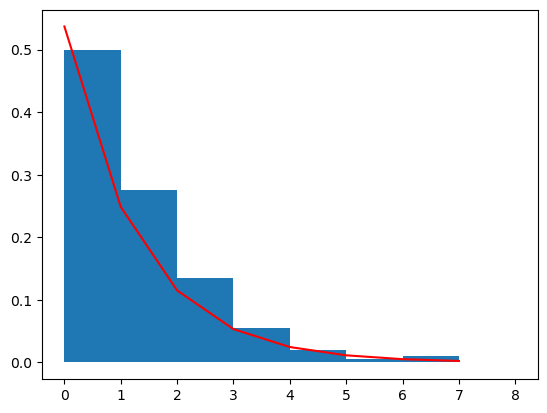

In [164]:
from matplotlib.patches import Rectangle
fig, ax = plt.subplots()
ax.plot(g4.p_eps, color = 'red')
#add rectangle to plot
j = 0
for i in range(len(g4.Wi)):
    ax.add_patch (Rectangle((j,0), 1, g4.Wi[i]))
    j += 1
#display plot
plt.show() 

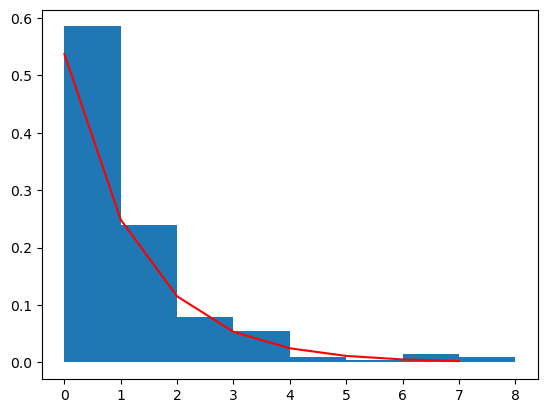

In [165]:
fig, ax = plt.subplots()
ax.plot(g4.p_eps, color = 'red')
#add rectangle to plot
j = 0
for i in range(len(g4.W2i)):
    ax.add_patch (Rectangle((j,0), 1, g4.W2i[i]))
    j += 1
#display plot
plt.show()

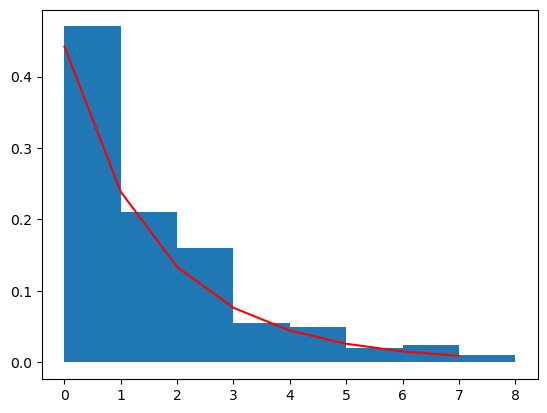

In [166]:
fig, ax = plt.subplots()
ax.plot(g5.p_eps, color = 'red')
#add rectangle to plot
j = 0
for i in range(len(g5.Wi)):
    ax.add_patch (Rectangle((j,0), 1, g5.Wi[i]))
    j += 1
#display plot
plt.show()

In [218]:
Text(g5.Xi2, g5.Xi22, g5.Xi_homogeneous, g5.loops)

сгенерированные случайные величины стандартным алгоритмом соответствуют распределению
Хи квадрат равен :  0.19573473149372245
сгенерированные случайные величины командой библиотеки scipy соответствуют распределению
Хи квадрат равен :  0.19573473149372245
выборки однородны
Хи квадрат для однородности :  -0.15999999999999837
Хи критическая : 15.50731305586545




In [169]:
save_to_excel(g4.table1, 'g4_table1')
save_to_excel(g4.table2, 'g4_table2')
save_to_excel(g5.table1, 'g5_table1')
save_to_excel(g5.table2, 'g5_table2')

save_to_excel(g4.Chi2_table1, 'g4_Xi2_t1')
save_to_excel(g4.Chi2_table2, 'g4_Xi2_t2')
save_to_excel(g4.Chi2_H_table,'g4_Xi2_tH')
save_to_excel(g5.Chi2_table1, 'g5_Xi2_t1')
save_to_excel(g5.Chi2_table2, 'g5_Xi2_t2')
save_to_excel(g5.Chi2_H_table,'g5_Xi2_tH')
  
save_table(g4.Eps_legacy1,g4.table_legacy1,'g4_array1_notsorted')
save_table(g4.Eps_legacy2,g4.table_legacy2,'g4_array2_notsorted')
save_table(g4.Eps_array,  g4.table_1,'g4_array1_sorted')
save_table(g4.Eps_array2, g4.table_2,'g4_array2_sorted')
save_table(g5.Eps_legacy1,g5.table_legacy1,'g5_array1_notsorted')
save_table(g5.Eps_legacy2,g5.table_legacy2,'g5_array2_notsorted')
save_table(g5.Eps_array  ,g5.table_1,'g5_array1_sorted')
save_table(g5.Eps_array2, g5.table_2,'g5_array2_sorted')
